# 02 Preprocessing

Run the reusable preprocessing pipeline and inspect the cleaned outputs.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import json
import pandas as pd

from src.preprocess import run_preprocessing
from src.data_utils import build_paths

metadata = run_preprocessing()
metadata

{'random_seed': 42,
 'raw_rows': 480,
 'rows_after_filtering': 377,
 'excluded_rows': 103,
 'duplicate_rows_dropped': 10,
 'invalid_label_rows': 3,
 'missing_text_rows': 0,
 'split_sizes': {'train': 263, 'val': 57, 'test': 57},
 'label_distribution': {'positive': 299, 'neutral': 54, 'negative': 24},
 'raw_files': ['Facebook_Comment_Annotation - Alfred.csv',
  'Facebook_Comment_Annotation - Fitina.csv',
  'Facebook_Comment_Annotation - Perpetual.csv',
  'Facebook_Comment_Annotation - Rahema.csv',
  'Facebook_Comment_Annotation - Thando.csv',
  'Facebook_Comment_Annotation - Viwongo.csv'],
 'split_indices': {'train': [75,
   178,
   124,
   295,
   472,
   183,
   246,
   409,
   224,
   298,
   410,
   133,
   411,
   104,
   385,
   417,
   0,
   442,
   340,
   208,
   10,
   471,
   313,
   301,
   359,
   318,
   399,
   278,
   252,
   293,
   446,
   281,
   109,
   331,
   317,
   314,
   388,
   248,
   61,
   18,
   347,
   171,
   266,
   89,
   288,
   419,
   147,
   114,
  

In [2]:
paths = build_paths()
cleaned = pd.read_csv(paths.interim_dir / 'cleaned_comments.csv')
cleaned[['text', 'cleaned_text', 'label']].head(20)

,text,cleaned_text,label
0,Republic of dowa 💥,republic of dowa 💥,negative
1,Under the dynamic of professor peter mnthalika...,under the dynamic of professor peter mnthalika...,neutral
2,Andale are waiting for this to stop him....,andale are waiting for this to stop him....,negative
3,A Malawian dangote,a malawian dangote,positive
4,"We do call this "" Japan in Malawi 🇲🇼""😁🙌","we do call this "" japan in malawi 🇲🇼 "" 😁🙌",positive
5,Waiting for IPO ya nzeru za bambo .. awa nde m...,waiting for ipo ya nzeru za bambo .. awa nde m...,positive
6,Dowa siku Malawi 🙌,dowa siku malawi 🙌,neutral
7,Politicians and 99 others feeling uncomfortabl...,politicians and <num> others feeling uncomfort...,negative
8,Real meaning of Pangolin,real meaning of pangolin,positive
9,Dollo kwambir ma small holder famers apindule,dollo kwambir ma small holder famers apindule,positive


In [4]:
cleaned.head(10)

,id,text,topic_label,sentiment_label,confidence,include,notes,source_file,sentiment_label_normalized,include_normalized,text_missing,text_length_chars,token_count_whitespace,is_short_comment,is_duplicate_text,exclude_reason,label,cleaned_text,tokens,token_count_cleaned
0,85,Republic of dowa 💥,Economy,Negative,High,Yes,NaN,Facebook_Comment_Annotation - Alfred.csv,negative,yes,False,18,4,False,False,NaN,negative,republic of dowa 💥,"['republic', 'of', 'dowa', '💥']",4
1,86,Under the dynamic of professor peter mnthalika...,Politics,Neutral,High,Yes,NaN,Facebook_Comment_Annotation - Alfred.csv,neutral,yes,False,50,8,False,False,NaN,neutral,under the dynamic of professor peter mnthalika...,"['under', 'the', 'dynamic', 'of', 'professor',...",8
2,87,Andale are waiting for this to stop him....,Politics,Negative,Medium,Yes,NaN,Facebook_Comment_Annotation - Alfred.csv,negative,yes,False,43,8,False,False,NaN,negative,andale are waiting for this to stop him....,"['andale', 'are', 'waiting', 'for', 'this', 't...",8
3,88,A Malawian dangote,Economy,Positive,High,Yes,NaN,Facebook_Comment_Annotation - Alfred.csv,positive,yes,False,18,3,False,False,NaN,positive,a malawian dangote,"['a', 'malawian', 'dangote']",3
4,89,"We do call this "" Japan in Malawi 🇲🇼""😁🙌",Economy,Positive,High,Yes,NaN,Facebook_Comment_Annotation - Alfred.csv,positive,yes,False,39,9,False,False,NaN,positive,"we do call this "" japan in malawi 🇲🇼 "" 😁🙌","['we', 'do', 'call', 'this', '""', 'japan', 'in...",11
5,90,Waiting for IPO ya nzeru za bambo .. awa nde m...,Economy,Positive,High,Yes,NaN,Facebook_Comment_Annotation - Alfred.csv,positive,yes,False,111,19,False,False,NaN,positive,waiting for ipo ya nzeru za bambo .. awa nde m...,"['waiting', 'for', 'ipo', 'ya', 'nzeru', 'za',...",19
6,91,Dowa siku Malawi 🙌,Politics,Neutral,High,Yes,NaN,Facebook_Comment_Annotation - Alfred.csv,neutral,yes,False,18,4,False,False,NaN,neutral,dowa siku malawi 🙌,"['dowa', 'siku', 'malawi', '🙌']",4
7,92,Politicians and 99 others feeling uncomfortabl...,Politics,Negative,Medium,Yes,NaN,Facebook_Comment_Annotation - Alfred.csv,negative,yes,False,74,11,False,False,NaN,negative,politicians and <num> others feeling uncomfort...,"['politicians', 'and', '<num>', 'others', 'fee...",11
8,93,Real meaning of Pangolin,Economy,Positive,High,Yes,NaN,Facebook_Comment_Annotation - Alfred.csv,positive,yes,False,24,4,False,False,NaN,positive,real meaning of pangolin,"['real', 'meaning', 'of', 'pangolin']",4
9,94,Dollo kwambir ma small holder famers apindule,Economy,Positive,High,Yes,NaN,Facebook_Comment_Annotation - Alfred.csv,positive,yes,False,45,7,False,False,NaN,positive,dollo kwambir ma small holder famers apindule,"['dollo', 'kwambir', 'ma', 'small', 'holder', ...",7


<Axes: xlabel='sentiment_label_normalized'>

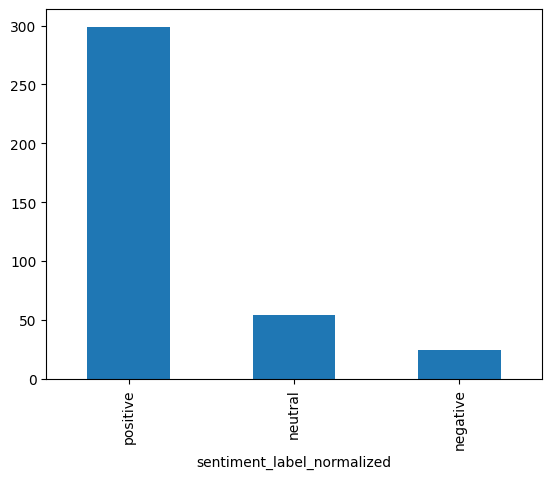

In [20]:
cleaned["sentiment_label_normalized"].value_counts().plot(kind='bar')

In [18]:
cleaned.sample(min(10, len(cleaned)), random_state=42)

,id,text,topic_label,sentiment_label,confidence,include,notes,source_file,sentiment_label_normalized,include_normalized,text_missing,text_length_chars,token_count_whitespace,is_short_comment,is_duplicate_text,exclude_reason,label,cleaned_text,tokens,token_count_cleaned
286,206,"Big brain never disappoint,,,,,,,, not izi am ...",Economy,Positive,High,Yes,NaN,Facebook_Comment_Annotation - Thando.csv,positive,yes,False,82,13,False,False,NaN,positive,"big brain never disappoint , , , , , , , , not...","['big', 'brain', 'never', 'disappoint', ',', '...",21
258,169,Thus a way to go as country 💥,Economy,Positive,High,Yes,approval,Facebook_Comment_Annotation - Thando.csv,positive,yes,False,29,8,False,False,NaN,positive,thus a way to go as country 💥,"['thus', 'a', 'way', 'to', 'go', 'as', 'countr...",8
262,178,The people from dowa we safe,Economy,Neutral,High,Yes,NaN,Facebook_Comment_Annotation - Thando.csv,neutral,yes,False,28,6,False,False,NaN,neutral,the people from dowa we safe,"['the', 'people', 'from', 'dowa', 'we', 'safe']",6
145,341,Pomwe ma politicians amakhala busy kudya mison...,Economy,positive,Medium,Yes,NaN,Facebook_Comment_Annotation - Perpetual.csv,positive,yes,False,119,21,False,False,NaN,positive,pomwe ma politicians amakhala busy kudya mison...,"['pomwe', 'ma', 'politicians', 'amakhala', 'bu...",21
55,142,The great great Man,Economy,Positive,High,Yes,NaN,Facebook_Comment_Annotation - Alfred.csv,positive,yes,False,19,4,False,False,NaN,positive,the great great man,"['the', 'great', 'great', 'man']",4
93,437,Zelu zabambo🔥,Economy,Positive,High,Yes,NaN,Facebook_Comment_Annotation - Fitina.csv,positive,yes,False,13,2,False,False,NaN,positive,zelu zabambo🔥,"['zelu', 'zabambo🔥']",2
339,22,Abomawa zimawavuta Pati?,Economy,Positive,High,Yes,NaN,Facebook_Comment_Annotation - Viwongo.csv,positive,yes,False,24,3,False,False,NaN,positive,abomawa zimawavuta pati?,"['abomawa', 'zimawavuta', 'pati?']",3
82,423,Malawian Dangote,Economy,Positive,High,Yes,NaN,Facebook_Comment_Annotation - Fitina.csv,positive,yes,False,16,2,False,False,NaN,positive,malawian dangote,"['malawian', 'dangote']",2
364,64,"Education is a key in America, who told you th...",Economy,Positive,High,Yes,NaN,Facebook_Comment_Annotation - Viwongo.csv,positive,yes,False,126,27,False,False,NaN,positive,"education is a key in america , who told you t...","['education', 'is', 'a', 'key', 'in', 'america...",28
148,345,President waku DOWA,Economy,Neutral,Medium,Yes,NaN,Facebook_Comment_Annotation - Perpetual.csv,neutral,yes,False,19,3,False,False,NaN,neutral,president waku dowa,"['president', 'waku', 'dowa']",3


In [9]:
train = pd.read_csv(paths.processed_dir / 'train.csv')
val = pd.read_csv(paths.processed_dir / 'val.csv')
test = pd.read_csv(paths.processed_dir / 'test.csv')
len(train), len(val), len(test)

(263, 57, 57)

<Axes: xlabel='sentiment_label_normalized'>

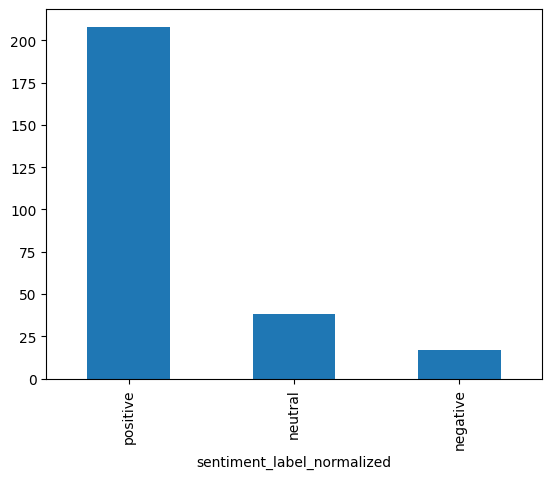

In [13]:
train['sentiment_label_normalized'].value_counts().plot(kind='bar')

<Axes: xlabel='sentiment_label_normalized'>

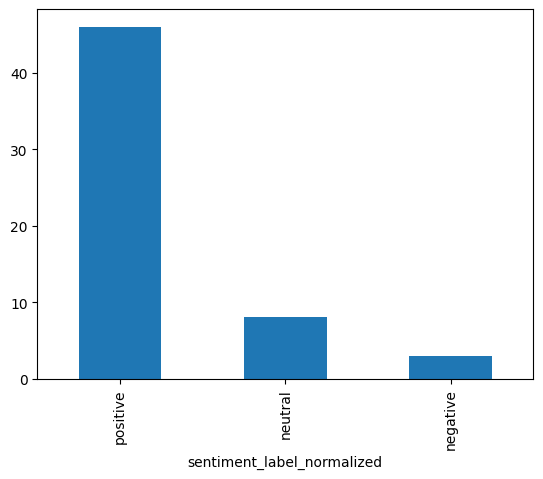

In [14]:
val['sentiment_label_normalized'].value_counts().plot(kind='bar')